In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score 
# Load 
df = pd.read_csv("/kaggle/input/datasets/karansridhar/marketing-and-product-performance/marketing_and_product_performance.csv")
df = df.dropna()

X = df.select_dtypes(include=np.number).drop(columns=['Revenue_Generated']) 
y = df['Revenue_Generated'] 

# Raw 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 

model = LinearRegression() 
model.fit(X_train, y_train) 
pred_raw = model.predict(X_test)

# Scaled 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

X_train_s, X_test_s, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2) 
model.fit(X_train_s, y_train) 
pred_scaled = model.predict(X_test_s)

df_table = pd.DataFrame({ 
    "Method": ["Raw","Scaled"], 
    "RMSE": [ 
        np.sqrt(mean_squared_error(y_test, pred_raw)), 
        np.sqrt(mean_squared_error(y_test, pred_scaled)) ], 
    "R2": [ 
        r2_score(y_test, pred_raw), 
        r2_score(y_test, pred_scaled) 
    ] 
})

df_table

,Method,RMSE,R2
0,Raw,28598.181874,-0.003178
1,Scaled,28564.781274,-0.000836


In [2]:
df_table.to_csv('/kaggle/working/table_rq3.csv', index=False)
print("Table saved")

Table saved


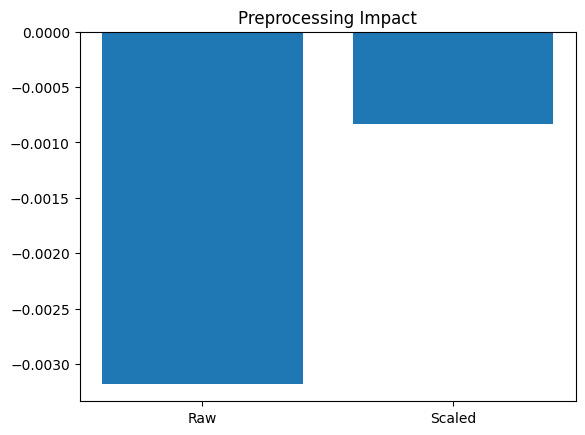

In [3]:
plt.figure() 
plt.bar(df_table["Method"], df_table["R2"]) 
plt.title("Preprocessing Impact") 
plt.savefig('/kaggle/working/figure_rq3.pdf') 
plt.show()